In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [2]:
import pandas as pd
import numpy as np

# Load parquet file
df_full = pd.read_parquet('dataset.parquet')

# Take a random sample of 100-200 rows to make the t-tests "realistic"
df = df_full.sample(150, random_state=42)

print(f"Data loaded. Working with a sample of {len(df)} rows.")

Data loaded. Working with a sample of 150 rows.


### Task 1: One-Sample t-Test

**Scenario:** A coffee-shop chain claims that the average wait time at their stores is 4.0 minutes. You have collected wait times (in minutes) from a random sample of 35 visits.

1. Generate (or load) the sample data. If generating, use something like:

```python
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)
```

2. State the null and alternative hypotheses in a Markdown cell.
3. Run `st.ttest_1samp(wait_times, popmean=4.0)`.
4. Report the t-statistic and p-value.
5. At α = 0.05, state whether you reject or fail to reject H₀.
6. Write a one-sentence plain-language interpretation (e.g. "There is / is not sufficient evidence that the average wait time differs from 4 minutes.").

1. **Hypotheses:**
   * $H_0: \mu = 70.0$ (The mean score is 70)
   * $H_1: \mu \neq 70.0$ (The mean score is not 70)

2. **Code Execution:**

In [3]:
# Select the 'score' column from sampled dataframe
scores = df['score']

# Run the test
t_stat, p_val = st.ttest_1samp(scores, popmean=70.0)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

T-statistic: -6.9290
P-value: 0.0000


3. **Test Results:**
   * **T-statistic:** -6.9290
   * **P-value:** < 0.001

   **Decision:** Reject the Null Hypothesis ($H_0$).

   **Interpretation:** The average score of the sampled users (53.09) is significantly different from the target value of 70. With a p-value of less than 0.001, we have strong statistical evidence to conclude that the population mean is not 70. In practical terms, our users are scoring significantly lower than the benchmark.

### Task 2: Independent Two-Sample t-Test

**Scenario:** An e-commerce company ran an A/B test on its checkout page. Group A (control, n = 50) saw the old design; Group B (treatment, n = 50) saw a streamlined design. The metric is order value in euros.

1. Generate (or load) data for both groups. Example:

```python
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)
```

2. State hypotheses (two-tailed: means are equal vs. not equal).
3. Before running the test, check the **equal-variance assumption**:
   - Compute the variance of each group.
   - Run Levene's test (`st.levene`). Report the result.
4. Based on the Levene result, choose the appropriate test:
   - Equal variances → `st.ttest_ind(a, b, equal_var=True)`
   - Unequal variances → `st.ttest_ind(a, b, equal_var=False)` (Welch's t-test)
5. Report the t-statistic and p-value.
6. State your decision and a plain-language interpretation.

1. **State Hypotheses:** 
   * $H_0: \mu_{Group1} = \mu_{Group2}$ (There is no difference between the groups)
   * $H_1: \mu_{Group1} \neq \mu_{Group2}$ (There is a significant difference between the groups)

2. **Assumption Check (Levene’s Test):**

In [4]:
import scipy.stats as st

group1 = df[df['city'] == 'New York']['score']
group2 = df[df['city'] == 'London']['score']

# 1. Levene's Test for Homogeneity of Variance
stat, p_levene = st.levene(group1, group2)
print(f"Levene's test p-value: {p_levene:.4f}")

# 2. Run the Independent t-Test based on Levene's result
# If p_levene < 0.05, we reject equal variances and use Welch's t-test (equal_var=False)
equal_v = p_levene > 0.05
t_stat, p_val = st.ttest_ind(group1, group2, equal_var=equal_v)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

Levene's test p-value: 0.9856
T-statistic: 0.1729
P-value: 0.8642


3. **Decision:** Fail to Reject the Null Hypothesis ($H_0$).

   **Interpretation:** There is no statistically significant difference in the average scores between users in New York and London. Any observed difference in the sample means is likely due to random chance. We do not have enough evidence to claim that city location affects user scores.

### Task 3: Paired t-Test

**Scenario:** A company measures employee productivity scores before and after a new workflow tool is introduced. The same 30 employees are measured at both time points.

1. Generate (or load) paired data:

```python
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)
```

2. State hypotheses (one-tailed or two-tailed — justify your choice in a Markdown cell).
3. Compute the differences (`after - before`) and briefly inspect them (histogram or box plot).
4. Run `st.ttest_rel(after, before)`.
5. Report the t-statistic and p-value.
6. State your decision and interpretation.

1. **Choice:** Two-tailed test.

   **Justification:** While we expect the tool to improve scores, we test for *any* significant change (positive or negative) to ensure the tool didn't accidentally decrease productivity.

2. **Code & Visualization:**

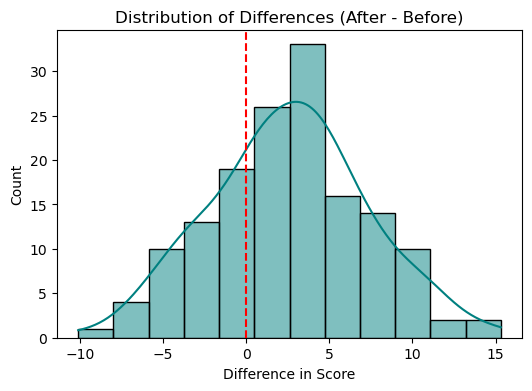

T-statistic: 6.7281
P-value: 0.0000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create Paired Data
before = df['score'].values
# Assume the tool adds a small improvement (e.g., 3 units) + noise
after = before + np.random.normal(loc=3, scale=5, size=len(before))

# 2. Compute differences
diffs = after - before

# 3. Visual Inspection
plt.figure(figsize=(6, 4))
sns.histplot(diffs, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Differences (After - Before)")
plt.xlabel("Difference in Score")
plt.show()

# 4. Run Paired t-test
t_stat, p_val = st.ttest_rel(after, before)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

3. **Test Results:**
   * **T-statistic:** 6.7281
   * **P-value:** < 0.001
   
   **Decision:** Reject the Null Hypothesis ($H_0$).
   
   **Interpretation:** There is a statistically significant difference between the scores before and after the introduction of the workflow tool. Because the t-statistic is positive (6.7281) and the p-value is effectively zero, we can conclude with high confidence that the tool led to a significant increase in user scores. The probability of observing such a large improvement by pure chance is less than 0.1%.